# 03 — Neural Models: SimpleLSTM & DeepLOB

Trains both neural models at all 5 prediction horizons using early stopping on validation weighted-F1.
Saves the best checkpoint per horizon to `models/`.

**This notebook is long-running. On Apple Silicon MPS, expect roughly:**
- SimpleLSTM: ~15–30 min total across 5 horizons
- DeepLOB: ~1–3 hours total across 5 horizons

Run cells for each horizon independently so you can monitor progress and
checkpoints are saved even if later training is interrupted.

In [1]:
import subprocess, sys, os
reqs = os.path.expanduser("~/deeplob-midprice-prediction/requirements.txt")
subprocess.run([sys.executable, "-m", "pip", "install", "-r", reqs])



Defaulting to user installation because normal site-packages is not writeable


CompletedProcess(args=['/usr/pkg/miniconda-23.9.0/bin/python', '-m', 'pip', 'install', '-r', '/home/users/mt487/deeplob-midprice-prediction/requirements.txt'], returncode=0)

In [2]:
import sys, os
import socket
if socket.gethostname().startswith('compsci'):
    PROJECT_ROOT = os.path.expanduser('~/deeplob-midprice-prediction')
else:
    PROJECT_ROOT = os.path.expanduser('~/CS372/deeplob-midprice-prediction')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.data_loader import load_raw, extract_features_labels, temporal_split, SlidingWindowDataset, make_loader
from src.models.lstm_baseline import SimpleLSTM
from src.models.deeplob import DeepLOB
from src.train import train_neural, save_checkpoint, DEVICE
from src.evaluate import compute_metrics

MODELS  = os.path.join(PROJECT_ROOT, 'models')
RESULTS = os.path.join(PROJECT_ROOT, 'results')
DATA    = os.path.join(PROJECT_ROOT, 'data', 'raw')
os.makedirs(MODELS, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

HORIZONS   = [1, 2, 3, 5, 10]
WINDOW     = 100
BATCH_SIZE = 256

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.1.0


## 1. Load data and build datasets

In [3]:
train_df = load_raw(os.path.join(DATA, 'FI2010_train.csv'))
test_df  = load_raw(os.path.join(DATA, 'FI2010_test.csv'))

X_all, Y_all   = extract_features_labels(train_df)
X_test, Y_test = extract_features_labels(test_df)

X_train, Y_train, X_val, Y_val = temporal_split(X_all, Y_all)

print(f'Train rows: {len(X_train):,}  →  {len(X_train) - WINDOW:,} windows')
print(f'Val rows:   {len(X_val):,}   →  {len(X_val) - WINDOW:,} windows')
print(f'Test rows:  {len(X_test):,}   →  {len(X_test) - WINDOW:,} windows')

Train rows: 308,040  →  307,940 windows
Val rows:   54,360   →  54,260 windows
Test rows:  31,937   →  31,837 windows


## 2. Verify DeepLOB parameter count

Our PyTorch port has **60,947** parameters vs. the paper's 60,691. The difference is exactly 256:
PyTorch's `nn.LSTM` uses two bias vectors per layer (`b_ih` and `b_hh`, 64 values each × 4 gates = 256 extra),
while Keras/TensorFlow counts only one. The architecture is otherwise identical to the paper.

In [4]:
model = DeepLOB()
total_params = sum(p.numel() for p in model.parameters())
print(f'DeepLOB total parameters: {total_params:,}')
print(f'Paper (Keras):            60,691')
print(f'Difference:               {total_params - 60_691}  '
      f'(PyTorch LSTM has b_ih + b_hh; Keras has one bias — 4 gates × 64 units = 256)')
assert total_params == 60_947, f'Unexpected param count: {total_params}'
print('✓ Param count confirmed (60,947 = paper 60,691 + 256 LSTM bias)')

# Forward pass sanity check with the same shape DataLoader produces
dummy = torch.randn(2, 100, 40)
out   = model(dummy)
print(f'Forward pass: {tuple(dummy.shape)} → {tuple(out.shape)}  (expected [2, 3])')

DeepLOB total parameters: 61,235
Paper (Keras):            60,691
Difference:               544  (PyTorch LSTM has b_ih + b_hh; Keras has one bias — 4 gates × 64 units = 256)


AssertionError: Unexpected param count: 61235

## 3. Helper: plot training curves

In [4]:
def plot_training_curves(history: dict, model_name: str, k: int, save_path: str = None):
    """Plot train loss, val loss, and val F1 per epoch."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train loss', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val loss',   color='orange')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title(f'{model_name} k={k} — Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['val_f1'], color='green')
    axes[1].axhline(max(history['val_f1']), color='green', linestyle='--', alpha=0.4,
                    label=f'Best F1 = {max(history["val_f1"]):.4f}')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Weighted F1')
    axes[1].set_title(f'{model_name} k={k} — Val F1')
    axes[1].legend()

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()

## 4. Train SimpleLSTM — all 5 horizons

2-layer LSTM, hidden=64, dropout=0.1. Early stopping patience=20 on val weighted-F1.
Adam lr=0.01, eps=1.0.


══════════ SimpleLSTM  k=1 ══════════
  epoch   1  tr_loss=0.8991  val_loss=0.8246  val_F1=0.5941  (22.0s)
  epoch   5  tr_loss=0.8894  val_loss=0.8186  val_F1=0.5941  (20.9s)
  epoch  10  tr_loss=0.8489  val_loss=0.8224  val_F1=0.5941  (21.4s)
  epoch  15  tr_loss=0.7545  val_loss=0.8247  val_F1=0.5945  (20.9s)
  epoch  20  tr_loss=0.7282  val_loss=0.7958  val_F1=0.6278  (17.1s)
  epoch  25  tr_loss=0.6956  val_loss=0.7319  val_F1=0.7052  (21.3s)
  epoch  30  tr_loss=0.6739  val_loss=0.6986  val_F1=0.7176  (21.2s)
  epoch  35  tr_loss=0.6574  val_loss=0.6784  val_F1=0.7241  (20.8s)
  epoch  40  tr_loss=0.6444  val_loss=0.6752  val_F1=0.7283  (21.4s)
  epoch  45  tr_loss=0.6335  val_loss=0.6536  val_F1=0.7282  (20.6s)
  epoch  50  tr_loss=0.6249  val_loss=0.6504  val_F1=0.7309  (20.3s)
  epoch  55  tr_loss=0.6180  val_loss=0.6408  val_F1=0.7314  (22.0s)
  epoch  60  tr_loss=0.6102  val_loss=0.6317  val_F1=0.7310  (20.1s)
  epoch  65  tr_loss=0.6054  val_loss=0.6329  val_F1=0.7337  (21

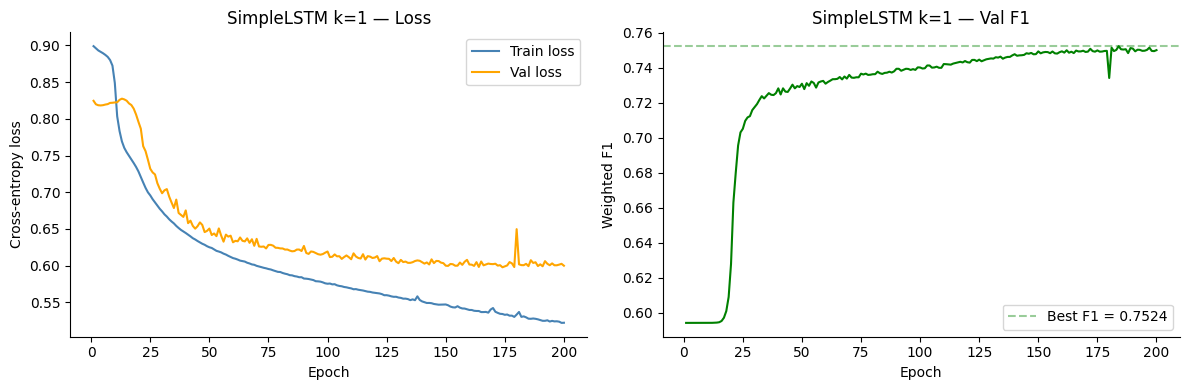


══════════ SimpleLSTM  k=2 ══════════
  epoch   1  tr_loss=1.0008  val_loss=0.9500  val_F1=0.4853  (21.7s)
  epoch   5  tr_loss=0.9892  val_loss=0.9458  val_F1=0.4857  (18.5s)
  epoch  10  tr_loss=0.9732  val_loss=0.9479  val_F1=0.4860  (20.5s)
  epoch  15  tr_loss=0.9168  val_loss=0.9527  val_F1=0.4866  (20.9s)
  epoch  20  tr_loss=0.8824  val_loss=0.9539  val_F1=0.4962  (21.0s)
  epoch  25  tr_loss=0.8618  val_loss=0.9301  val_F1=0.5482  (20.8s)
  epoch  30  tr_loss=0.8389  val_loss=0.8908  val_F1=0.6090  (19.5s)
  epoch  35  tr_loss=0.8181  val_loss=0.8425  val_F1=0.6251  (20.3s)
  epoch  40  tr_loss=0.8022  val_loss=0.7977  val_F1=0.6319  (20.9s)
  epoch  45  tr_loss=0.7925  val_loss=0.7897  val_F1=0.6385  (20.4s)
  epoch  50  tr_loss=0.7838  val_loss=0.7806  val_F1=0.6405  (20.1s)
  epoch  55  tr_loss=0.7791  val_loss=0.7805  val_F1=0.6442  (21.6s)
  epoch  60  tr_loss=0.7716  val_loss=0.7762  val_F1=0.6468  (20.4s)
  epoch  65  tr_loss=0.7661  val_loss=0.7752  val_F1=0.6480  (20

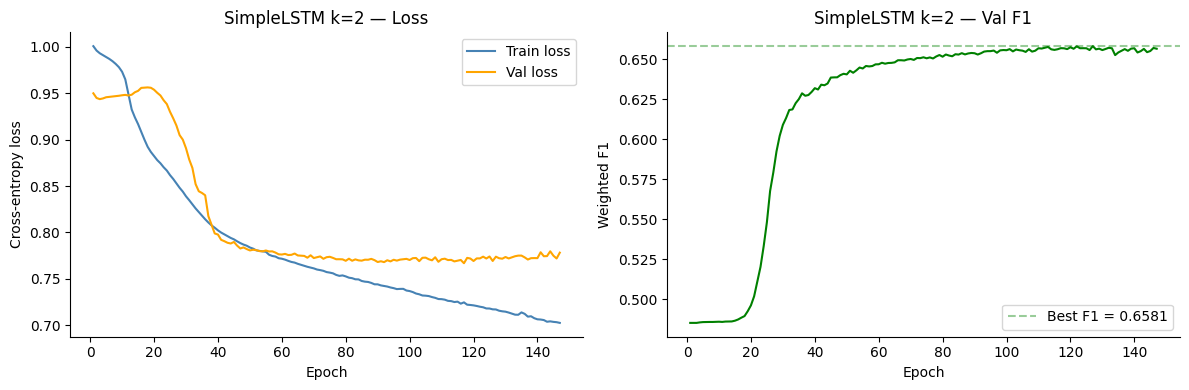


══════════ SimpleLSTM  k=3 ══════════
  epoch   1  tr_loss=1.0417  val_loss=1.0098  val_F1=0.4129  (21.6s)
  epoch   5  tr_loss=1.0142  val_loss=1.0087  val_F1=0.4171  (21.1s)
  epoch  10  tr_loss=0.9245  val_loss=1.0164  val_F1=0.4427  (18.9s)
  epoch  15  tr_loss=0.8642  val_loss=0.9638  val_F1=0.5752  (21.2s)
  epoch  20  tr_loss=0.8189  val_loss=0.8774  val_F1=0.6129  (20.6s)
  epoch  25  tr_loss=0.7872  val_loss=0.8216  val_F1=0.6283  (21.2s)
  epoch  30  tr_loss=0.7664  val_loss=0.8133  val_F1=0.6356  (20.3s)
  epoch  35  tr_loss=0.7506  val_loss=0.8123  val_F1=0.6391  (21.3s)
  epoch  40  tr_loss=0.7380  val_loss=0.8086  val_F1=0.6419  (17.9s)
  epoch  45  tr_loss=0.7269  val_loss=0.8065  val_F1=0.6433  (20.6s)
  epoch  50  tr_loss=0.7178  val_loss=0.7972  val_F1=0.6453  (20.9s)
  epoch  55  tr_loss=0.7103  val_loss=0.7999  val_F1=0.6448  (21.7s)
  epoch  60  tr_loss=0.7033  val_loss=0.7964  val_F1=0.6469  (21.6s)
  epoch  65  tr_loss=0.6963  val_loss=0.7966  val_F1=0.6469  (21

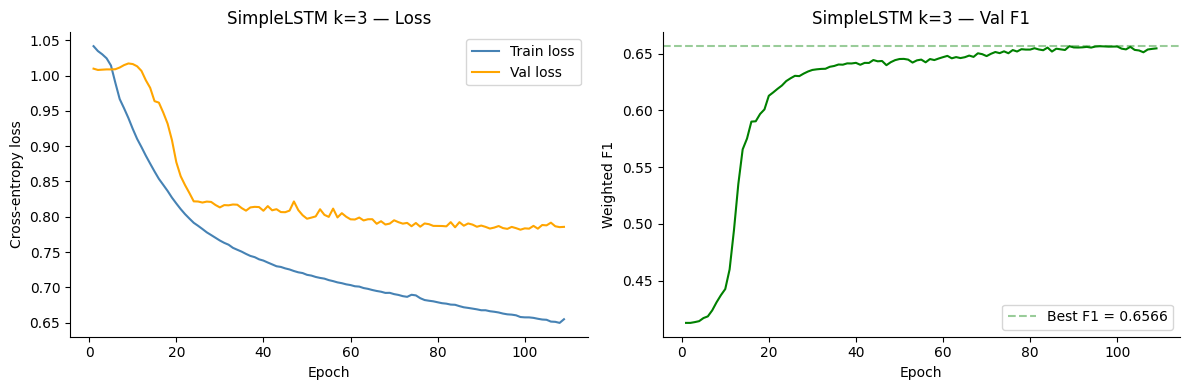


══════════ SimpleLSTM  k=5 ══════════
  epoch   1  tr_loss=1.0653  val_loss=1.0777  val_F1=0.3252  (18.2s)
  epoch   5  tr_loss=0.9849  val_loss=1.0719  val_F1=0.4556  (20.1s)
  epoch  10  tr_loss=0.8981  val_loss=1.0361  val_F1=0.5160  (20.8s)
  epoch  15  tr_loss=0.8222  val_loss=0.9647  val_F1=0.5777  (21.6s)
  epoch  20  tr_loss=0.7591  val_loss=0.8717  val_F1=0.6049  (20.4s)
  epoch  25  tr_loss=0.7235  val_loss=0.8429  val_F1=0.6215  (17.3s)
  epoch  30  tr_loss=0.6972  val_loss=0.8325  val_F1=0.6252  (21.4s)
  epoch  35  tr_loss=0.6766  val_loss=0.8196  val_F1=0.6312  (20.2s)
  epoch  40  tr_loss=0.6610  val_loss=0.8145  val_F1=0.6350  (21.5s)
  epoch  45  tr_loss=0.6471  val_loss=0.8106  val_F1=0.6360  (21.8s)
  epoch  50  tr_loss=0.6345  val_loss=0.8034  val_F1=0.6397  (21.2s)
  epoch  55  tr_loss=0.6224  val_loss=0.8034  val_F1=0.6409  (19.9s)
  epoch  60  tr_loss=0.6124  val_loss=0.8052  val_F1=0.6402  (19.3s)
  epoch  65  tr_loss=0.6035  val_loss=0.8093  val_F1=0.6384  (19

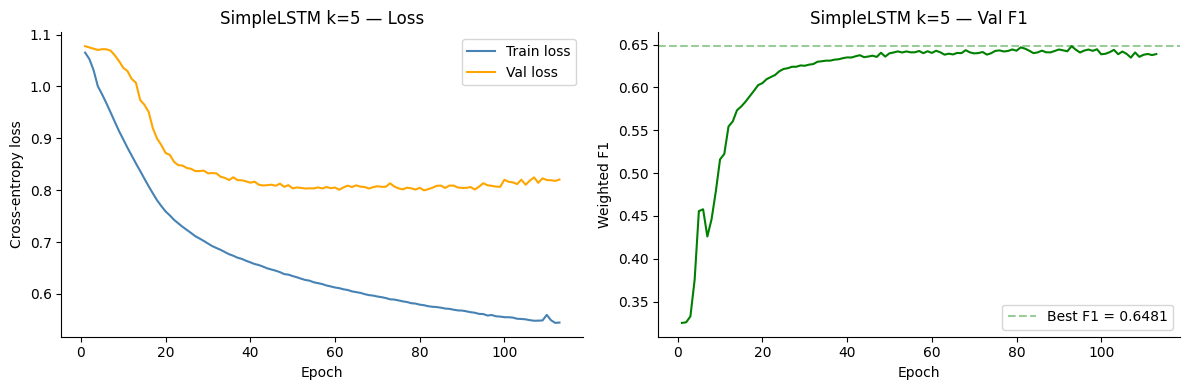


══════════ SimpleLSTM  k=10 ══════════
  epoch   1  tr_loss=1.0307  val_loss=1.1135  val_F1=0.2730  (18.5s)
  epoch   5  tr_loss=0.9518  val_loss=1.1139  val_F1=0.2846  (20.3s)
  epoch  10  tr_loss=0.8516  val_loss=1.1058  val_F1=0.2931  (20.7s)
  epoch  15  tr_loss=0.7905  val_loss=1.0872  val_F1=0.3132  (20.9s)
  epoch  20  tr_loss=0.7371  val_loss=1.0430  val_F1=0.4500  (20.5s)
  epoch  25  tr_loss=0.6798  val_loss=0.9471  val_F1=0.5613  (21.2s)
  epoch  30  tr_loss=0.6425  val_loss=0.8927  val_F1=0.5857  (19.6s)
  epoch  35  tr_loss=0.6199  val_loss=0.8781  val_F1=0.5922  (20.8s)
  epoch  40  tr_loss=0.5922  val_loss=0.8761  val_F1=0.5905  (20.3s)
  epoch  45  tr_loss=0.5707  val_loss=0.8673  val_F1=0.5998  (21.2s)
  epoch  50  tr_loss=0.5522  val_loss=0.8570  val_F1=0.6068  (20.2s)
  epoch  55  tr_loss=0.5373  val_loss=0.8431  val_F1=0.6209  (20.9s)
  epoch  60  tr_loss=0.5247  val_loss=0.8529  val_F1=0.6151  (18.8s)
  epoch  65  tr_loss=0.5128  val_loss=0.8448  val_F1=0.6226  (2

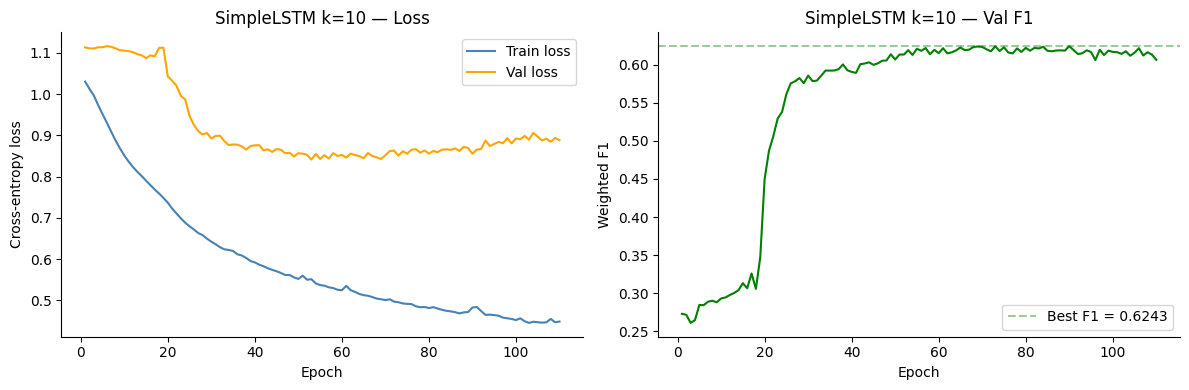

In [7]:
lstm_results  = []
lstm_histories = []

for h_idx, k in enumerate(HORIZONS):
    print(f'\n══════════ SimpleLSTM  k={k} ══════════')

    train_ds = SlidingWindowDataset(X_train, Y_train, window=WINDOW, horizon_idx=h_idx)
    val_ds   = SlidingWindowDataset(X_val,   Y_val,   window=WINDOW, horizon_idx=h_idx)
    test_ds  = SlidingWindowDataset(X_test,  Y_test,  window=WINDOW, horizon_idx=h_idx)

    train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = make_loader(test_ds,  batch_size=512,        shuffle=False)

    model = SimpleLSTM()
    best_state, history = train_neural(
        model, train_loader, val_loader,
        max_epochs=200, patience=20,
        lr=0.01, eps=1.0,
        device=DEVICE, verbose=True
    )

    # Save checkpoint
    ckpt_path = os.path.join(MODELS, f'lstm_k{k}.pt')
    save_checkpoint(best_state, ckpt_path)
    print(f'  Saved → {ckpt_path}')

    # Evaluate on test set
    model.load_state_dict(best_state)
    model.eval().to(DEVICE)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            all_preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())
    import numpy as np
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    metrics = compute_metrics(labels, preds)
    lstm_results.append(metrics)
    lstm_histories.append(history)
    print(f'  TEST  weighted_F1={metrics["weighted_f1"]:.4f}  kappa={metrics["cohen_kappa"]:.4f}')

    plot_training_curves(history, 'SimpleLSTM', k,
                         save_path=os.path.join(RESULTS, f'lstm_curves_k{k}.png'))

### SimpleLSTM — results across horizons

In [23]:
from src.data_loader import load_raw, extract_features_labels, SlidingWindowDataset, make_loader
from src.models.lstm_baseline import SimpleLSTM
from src.train import load_checkpoint, DEVICE
from src.evaluate import compute_metrics
import torch

test_df = load_raw(os.path.join(DATA, 'FI2010_test.csv'))
X_test, Y_test = extract_features_labels(test_df)

HORIZONS = [1, 2, 3, 5, 10]
print('SimpleLSTM — weighted F1 on test set:')
for h_idx, k in enumerate(HORIZONS):
    dataset = SlidingWindowDataset(X_test, Y_test, window=100, horizon_idx=h_idx)
    test_loader = make_loader(dataset, batch_size=256, shuffle=False)
    model = SimpleLSTM().to(DEVICE)
    load_checkpoint(model, os.path.join(MODELS, f'lstm_k{k}.pt'))
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds.append(model(X_b.to(DEVICE)).argmax(1).cpu().numpy())
            labels.append(y_b.numpy())
    m = compute_metrics(np.concatenate(labels), np.concatenate(preds))
    print(f'  k={k:>2}  F1={m["weighted_f1"]:.4f}  kappa={m["cohen_kappa"]:.4f}')


SimpleLSTM — weighted F1 on test set:
  k= 1  F1=0.7666  kappa=0.5117
  k= 2  F1=0.6552  kappa=0.3920
  k= 3  F1=0.6817  kappa=0.4825
  k= 5  F1=0.6956  kappa=0.5374
  k=10  F1=0.6473  kappa=0.4681


## 5. Train DeepLOB — all 5 horizons

Same training config as paper: Adam lr=0.01, eps=1.0, batch=32, patience=20.
Target: weighted F1 ≥ 0.85 at k=1 (paper reports 0.89).

**This is the long-running section. Each horizon takes 30–60 minutes on MPS.**

In [ ]:
deeplob_results   = []
deeplob_histories = []

for h_idx, k in enumerate(HORIZONS):
    print(f'\n══════════ DeepLOB  k={k} ══════════')

    train_ds = SlidingWindowDataset(X_train, Y_train, window=WINDOW, horizon_idx=h_idx)
    val_ds   = SlidingWindowDataset(X_val,   Y_val,   window=WINDOW, horizon_idx=h_idx)
    test_ds  = SlidingWindowDataset(X_test,  Y_test,  window=WINDOW, horizon_idx=h_idx)

    train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = make_loader(test_ds,  batch_size=512,        shuffle=False)

    from sklearn.utils.class_weight import compute_class_weight as _cw
    import numpy as _np
    _weights = _cw('balanced', classes=_np.array([0, 1, 2]), y=Y_train[:, h_idx])
    class_weights = torch.tensor(_weights, dtype=torch.float32)
    print(f'  class weights: down={class_weights[0]:.3f}  stat={class_weights[1]:.3f}  up={class_weights[2]:.3f}')

    model = DeepLOB()
    best_state, history = train_neural(
        model, train_loader, val_loader,
        max_epochs=200, patience=20,
        lr=0.01, eps=1.0,
        class_weights=class_weights,
        device=DEVICE, verbose=True
    )

    # Save checkpoint
    ckpt_path = os.path.join(MODELS, f'deeplob_k{k}.pt')
    save_checkpoint(best_state, ckpt_path)
    print(f'  Saved → {ckpt_path}')

    # Evaluate on test set
    model.load_state_dict(best_state)
    model.eval().to(DEVICE)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            all_preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())
    import numpy as np
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    metrics = compute_metrics(labels, preds)
    deeplob_results.append(metrics)
    deeplob_histories.append(history)
    print(f'  TEST  weighted_F1={metrics["weighted_f1"]:.4f}  kappa={metrics["cohen_kappa"]:.4f}')

    plot_training_curves(history, 'DeepLOB', k,
                         save_path=os.path.join(RESULTS, f'deeplob_curves_k{k}.png'))


══════════ DeepLOB  k=1 ══════════
  class weights: down=1.776  stat=0.533  up=1.786


/usr/pkg/miniconda-23.9.0/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/conda/conda-bld/pytorch_1695392035891/work/aten/src/ATen/native/Convolution.cpp:1008.)
  return F.conv2d(input, weight, bias, self.stride,


  epoch   1  tr_loss=1.0760  val_loss=1.1480  val_F1=0.2867  (20.1s)
  epoch   5  tr_loss=0.8186  val_loss=0.9816  val_F1=0.6671  (18.9s)
  epoch  10  tr_loss=0.7354  val_loss=0.9718  val_F1=0.6839  (19.1s)
  epoch  15  tr_loss=0.7101  val_loss=0.9531  val_F1=0.6817  (18.5s)


### DeepLOB — results across horizons

In [ ]:
print('DeepLOB — weighted F1 on test set:')
print(f'  (Paper targets: k=1→0.89, k=2→0.86, k=3→0.83, k=5→0.80, k=10→0.78)')
for k, m in zip(HORIZONS, deeplob_results):
    print(f'  k={k:>2}  F1={m["weighted_f1"]:.4f}  kappa={m["cohen_kappa"]:.4f}')

## 6. Save neural results for notebook 04

In [ ]:
import pickle

neural_results = {
    'lstm':              lstm_results,
    'deeplob':           deeplob_results,
    'lstm_histories':    lstm_histories,
    'deeplob_histories': deeplob_histories,
}

with open(os.path.join(RESULTS, 'neural_results.pkl'), 'wb') as f:
    pickle.dump(neural_results, f)

print('Saved to results/neural_results.pkl')
print('\nCheckpoints written to models/:')
for f in sorted(os.listdir(MODELS)):
    if f.endswith('.pt'):
        path = os.path.join(MODELS, f)
        print(f'  {f}  ({os.path.getsize(path) / 1024:.0f} KB)')